## 7d. Remote At Outer Arms with choice

In [1]:
%reload_ext autoreload
%autoreload 2

In [75]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums
import seaborn as sns
import copy
import random
from scipy import stats

In [22]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new, classify_remote_chosen_theta_animal

In [466]:
def normalize(posterior_chosen, posterior_unchosen, event_indices, num_of_bins):
    #posterior_sum = posterior_chosen + np.sum(posterior_unchosen, 1).reshape((-1,1))
    #posterior_chosen_normalized = posterior_chosen / posterior_sum
    #posterior_unchosen_normalized = posterior_unchosen / posterior_sum
    posterior_chosen_normalized = posterior_chosen / num_of_bins[event_indices]
    posterior_unchosen_normalized = posterior_unchosen / num_of_bins[event_indices]
    
    return posterior_chosen_normalized, posterior_unchosen_normalized

In [533]:
# basic test
def test(event_indices, chosen_arm, unchosen_arm, posterior_arm_np, trial_info_arm):
    print("These trials have large chosen arm decode")
    
    event_ind = np.array(event_indices)[(chosen_arm>0.1).ravel()] #order in the original dataset
    print(np.array(trial_info_arm)[event_ind])

    event_ind2 = np.array(event_indices)[(unchosen_arm[:,0]>0.05).ravel() + (unchosen_arm[:,1]>0.05).ravel() ] #order in the original dataset
    print("These trials have large unchosen arm decode")
    print(np.array(trial_info_arm)[event_ind2])

    if len(event_ind) < 2:
        print("not much data to check, test aborted")
        return None
        
    id1 = event_ind[0]
    id2 = event_ind[-1]
    
    test_answer1 = posterior_arm_np[id1] / num_of_bins_arm[id1]
    test_answer2 = posterior_arm_np[id2] / num_of_bins_arm[id2]
    
    assert np.isin( (chosen_arm[chosen_arm>0.1])[0] , test_answer1)
    assert np.isin( (chosen_arm[chosen_arm>0.1])[-1] , test_answer2)
    print("Test passed")
    
    
    return None

In [4]:
# Algorithm
# for each trial:
# select time bins the animal is running outbound at 5 cm/s on home arm
#     for each home arm bins:
#        use 1D position info to find sum across time bins that animal is in that home arm bin
#        sum posterior at all bins within home arm
#

# for each trial:
# select time bins the animal is within center platform, by 2D position
# sum across time bins that animal is in that home arm bin
# sum posterior at all bins within all outer arms

### post- change of mind, when the animal is on the arm, on the center platform, or combined.

In [320]:
params_arm = {"use_1d": False,
          "use_home": False,
          "use_center": False,
          "use_outer": True,
          "use_all_outers": True,
          "proportion":0.1,
          "delta_t_minus":0,
          "delta_t_plus":2,
          "segment_only":True,
          "speed_threshold":None,
          "normalized": False,
          "max_flag": 0}

params_center = {"use_1d": False,
          "use_home": False,
          "use_center": True,
          "use_outer": False,
          "use_all_outers": True,
          "proportion":0.1,
          "delta_t_minus":0,
          "delta_t_plus":2,
          "segment_only":True,
          "speed_threshold":None,
          "normalized": False,
          "max_flag": 0}

### rats

In [208]:
animal = "eliot"
list_of_days = ["20221020","20221021"]

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [538]:
animal = 'Lewis'
list_of_days = ['20240109','20240110']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [552]:
animal = 'Molly'
list_of_days = ['20220418']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

## Get data

In [553]:
# find all outer arm representation
posterior_arm, trial_info_arm, num_of_bins_arm = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,**params_arm)
posterior_arm_np = np.array(posterior_arm).squeeze()

posterior_center, trial_info_center, num_of_bins_center = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,**params_center)
posterior_center_np = np.array(posterior_center).squeeze()

assert len(posterior_arm) == len(num_of_bins_arm)
assert len(posterior_center) == len(num_of_bins_center)

[17:57:04][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[2025-10-02 17:57:05,029][WARNING]: Skipped checksum for file with hash: cc001042-33da-41d7-1be5-1205b54fef20, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_BCOAGHZMHX.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/molly_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220418_p0.1_tm0_tp2_maxflag0_controlFalse.pkl':
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 2         0.1            molly20220418_ acbac987-4f03-
 (Total: 1)

working on event_index0
working on event_index1
working on event_index2
working on event_index3
working on event_index4
working on event_index5
working on event_index6


[2025-10-02 17:57:25,466][WARNING]: Skipped checksum for file with hash: cca84244-9b1d-0c46-08da-f1681353203b, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_YUQEMQN4RC.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 4         0.1            molly20220418_ 5320ceea-a66d-
 (Total: 1)

working on event_index7
working on event_index8
working on event_index9
working on event_index10
working on event_index11


[2025-10-02 17:57:42,300][WARNING]: Skipped checksum for file with hash: a2526d29-c46e-1b33-882f-748ea127112b, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_8FMT60XN45.nwb


...

*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 6         0.1            molly20220418_ 7e2ae23a-750c-
 (Total: 1)

working on event_index12
working on event_index13
working on event_index14
working on event_index15
working on event_index16
working on event_index17
working on event_index18
working on event_index19
working on event_index20
working on event_index21
working on event_index22


[2025-10-02 17:59:35,150][WARNING]: Skipped checksum for file with hash: 526ecb88-882e-41cd-5ab0-72439ed486e8, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_SMLP4CD1V4.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 8         0.1            molly20220418_ 97a7e5fc-a97e-
 (Total: 1)

working on event_index23
working on event_index24
working on event_index25
working on event_index26
working on event_index27
working on event_index28
working on event_index29
working on event_index30
working on event_index31


[2025-10-02 17:59:50,198][WARNING]: Skipped checksum for file with hash: 2c4072f5-0648-3270-96f2-c0498ad0c8f4, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_3QW9OXXMQC.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 10        0.1            molly20220418_ 8c874b40-5a70-
 (Total: 1)

working on event_index32
working on event_index33
working on event_index34
working on event_index35
working on event_index36
working on event_index37
working on event_index38
working on event_index39
working on event_index40
working on event_index41


In [555]:
# move some arm to the category "chosen" and move other arms to the category "unchosen" 
# in addition, some trials are not included because they have multiple change of mind
# or the final arm choice and initial change of mind arm choice are the same
# normalize by time is false because we will do that in the next cell block!

posterior_chosen_arm, posterior_unchosen_arm, event_indices = classify_remote_chosen_theta_animal(
    animal,list_of_days, posterior_arm_np, trial_info_arm, proportion = params_arm["proportion"], normalized = False)

posterior_chosen_center, posterior_unchosen_center, event_indices = classify_remote_chosen_theta_animal(
    animal,list_of_days, posterior_center_np, trial_info_center, proportion = params_arm["proportion"], normalized = False)

[2025-10-02 18:03:30,723][WARNING]: Skipped checksum for file with hash: cc001042-33da-41d7-1be5-1205b54fef20, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_BCOAGHZMHX.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 2         0.1            molly20220418_ acbac987-4f03-
 (Total: 1)



[2025-10-02 18:03:40,761][WARNING]: Skipped checksum for file with hash: cca84244-9b1d-0c46-08da-f1681353203b, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_YUQEMQN4RC.nwb


working on event_index0
working on event_index1
working on event_index2
working on event_index3
working on event_index4
working on event_index5
working on event_index6
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 4         0.1            molly20220418_ 5320ceea-a66d-
 (Total: 1)



[2025-10-02 18:03:50,830][WARNING]: Skipped checksum for file with hash: a2526d29-c46e-1b33-882f-748ea127112b, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_8FMT60XN45.nwb


...

working on event_index7
working on event_index8
working on event_index9
working on event_index10
working on event_index11
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 6         0.1            molly20220418_ 7e2ae23a-750c-
 (Total: 1)



[2025-10-02 18:04:54,573][WARNING]: Skipped checksum for file with hash: 526ecb88-882e-41cd-5ab0-72439ed486e8, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_SMLP4CD1V4.nwb


working on event_index12
working on event_index13
working on event_index14
working on event_index15
working on event_index16
working on event_index17
working on event_index18
working on event_index19
working on event_index20
working on event_index21
working on event_index22
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 8         0.1            molly20220418_ 97a7e5fc-a97e-
 (Total: 1)



[2025-10-02 18:05:05,657][WARNING]: Skipped checksum for file with hash: 2c4072f5-0648-3270-96f2-c0498ad0c8f4, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_3QW9OXXMQC.nwb


working on event_index23
working on event_index24
working on event_index25
working on event_index26
working on event_index27
working on event_index28
working on event_index29
working on event_index30
working on event_index31
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     
+------------+ +-------+ +------------+ +------------+ +------------+
molly20220418_ 10        0.1            molly20220418_ 8c874b40-5a70-
 (Total: 1)

working on event_index32
working on event_index33
working on event_index34
working on event_index35
working on event_index36
working on event_index37
working on event_index38
working on event_index39
working on event_index40
working on event_index41


In [556]:
# normalized by time
num_of_bins_arm = np.array(num_of_bins_arm).squeeze().reshape((-1,1))
num_of_bins_center = np.array(num_of_bins_center).squeeze().reshape((-1,1))

posterior_chosen_arm = np.array(posterior_chosen_arm).reshape((-1,1))
posterior_unchosen_arm = np.array(posterior_unchosen_arm).reshape((-1,2))
chosen_arm, unchosen_arm = normalize(
    posterior_chosen_arm, posterior_unchosen_arm, event_indices, num_of_bins_arm)

posterior_chosen_center = np.array(posterior_chosen_center).reshape((-1,1))
posterior_unchosen_center = np.array(posterior_unchosen_center).reshape((-1,2))
chosen_center, unchosen_center = normalize(
    posterior_chosen_center, posterior_unchosen_center, event_indices, num_of_bins_center)

# combine arm and center
posterior_chosen_combined = posterior_chosen_arm + posterior_chosen_center
posterior_unchosen_combined = posterior_unchosen_arm + posterior_unchosen_center
num_of_bins_combined = num_of_bins_arm + num_of_bins_center
chosen_combined, unchosen_combined = normalize(
    posterior_chosen_combined, posterior_unchosen_combined, event_indices, num_of_bins_combined)

In [557]:
# print sessions and trials with large posterior for the chosen arm

test(event_indices, chosen_arm, unchosen_arm, posterior_arm_np, trial_info_arm)

These trials have large chosen arm decode
[]
These trials have large unchosen arm decode
[['molly20220418_.nwb' '06_Seq2Session3' '39' '2']]
not much data to check, test aborted


### paired plot

In [ ]:
def paired_plot(posterior_chosen, posterior_unchosen, list_of_days, title):
    posterior_unchosen_matched = [
        posterior_unchosen[trial_ind][random.choice(np.arange(len(posterior_unchosen[trial_ind])))] for trial_ind in range(len(posterior_unchosen))]
    print(len(posterior_unchosen_matched))

    posterior_chosen = posterior_chosen.ravel().tolist()

    
    fig,axe = plt.subplots(1,1,figsize = (5,3))

    label1 = "posterior_chosen"
    label2 = "posterior_unchosen"
    for trial_ind in range(len(posterior_unchosen)):
        axe.plot([0,1],[np.log(posterior_chosen[trial_ind]),np.log(posterior_unchosen_matched[trial_ind])],color = 'k',alpha = 0.5)
    
    t_statistic, p_value = stats.ttest_rel(posterior_chosen, posterior_unchosen_matched)
    print("p_value",p_value)
    if p_value < 0.05:
        # adding statistical annotation
        annotations = [(label1, label2, np.round(p_value, 4))]
        starbars.draw_annotation(annotations)
    
    axe.set_xticks([0,1])
    axe.set_xticklabels([label1,label2])  
    axe.set_title(f"{animal}\n{list_of_days}\nsum of posterior in outer arm \n animal in {title}")
    axe.set_ylabel("log(probability)")
    #axe.set_ylim([0,np.quantile(posterior_chosen,0.99)])

    return axe

63
p_value 0.9727767656364437
63
p_value 0.37502645222621434
63
p_value 0.7781755283952856


<Axes: title={'center': "Lewis\n['20240109', '20240110']\nsum of posterior in outer arm \n animal in combined"}, ylabel='log(probability)'>

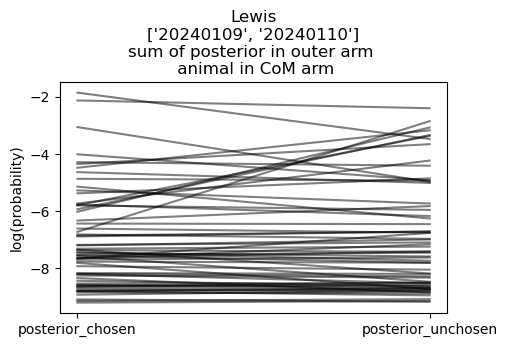

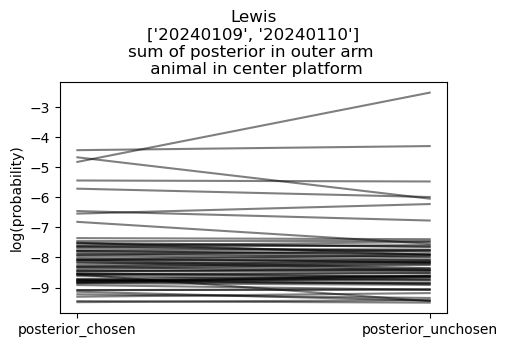

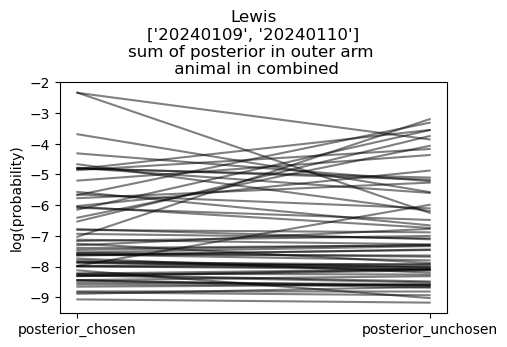

In [549]:
paired_plot(chosen_arm, unchosen_arm, list_of_days, "CoM arm")
paired_plot(chosen_center, unchosen_center, list_of_days, "center platform")
paired_plot(chosen_combined, unchosen_combined, list_of_days, "combined")

### unpaired plot

In [550]:
def unpaired_plot(posterior_chosen, posterior_unchosen, list_of_days, title):
    fig,axes = plt.subplots(1,2,figsize = (10,3))
    
    axe = axes[0]
    violin_dict = {}
    label1 = "posterior_chosen"
    label2 = "posterior_unchosen"
    
    posterior_unchosen_subset = np.concatenate(posterior_unchosen)
    violin_dict[label1] = posterior_chosen.ravel().tolist()
    violin_dict[label2] = posterior_unchosen_subset
    
    xticks = [f"{label} \n N = {len(violin_dict[label])}" for label in violin_dict]
                                
    ax = sns.violinplot(violin_dict, width=0.5, ax = axe)
    _, p_value = ranksums(violin_dict[label1], violin_dict[label2])
    print("p_value",p_value)
    if p_value < 0.05:
        # adding statistical annotation
        annotations = [(label1, label2, np.round(p_value, 4))]
        starbars.draw_annotation(annotations)
        
    axe.set_title(f"{animal}\n{list_of_days}\nsum of posterior in outer arm \n animal in {title}")
    axe.set_ylabel("probability")
    
    axe = axes[1]
    axe.hist(posterior_chosen, density = True , alpha = 0.5)
    axe.hist(posterior_unchosen_subset, density = True, alpha = 0.5)

    return axes

p_value 0.9774969829381552
p_value 0.7286309860928188
p_value 0.9842468227991462


array([<Axes: title={'center': "Lewis\n['20240109', '20240110']\nsum of posterior in outer arm \n animal in combined"}, ylabel='probability'>,
       <Axes: >], dtype=object)

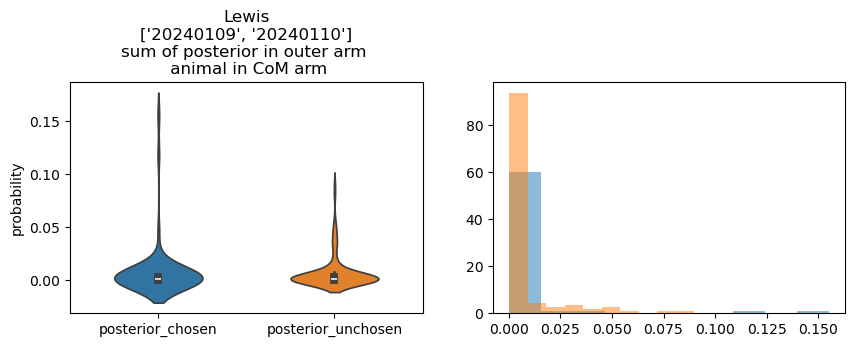

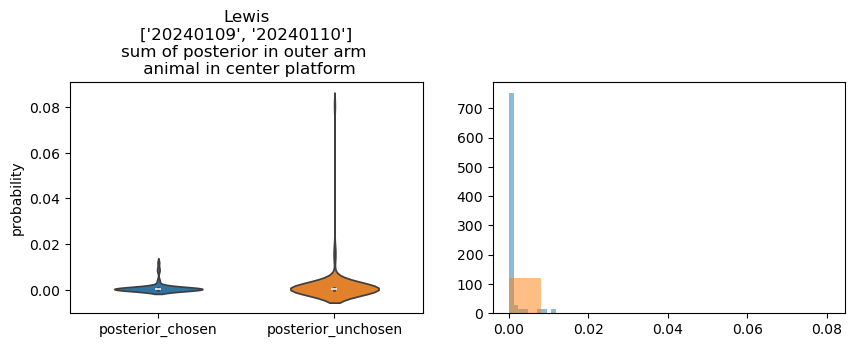

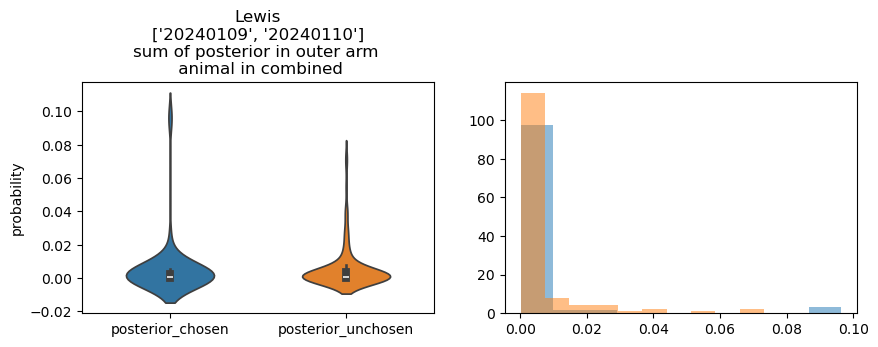

In [551]:
unpaired_plot(chosen_arm, unchosen_arm, list_of_days, "CoM arm")
unpaired_plot(chosen_center, unchosen_center, list_of_days, "center platform")
unpaired_plot(chosen_combined, unchosen_combined, list_of_days, "combined")